# Book_Rating_Predictor

## Importing the necessary librairies

In [1]:
import pandas as pd
import linecache
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

## Exploratory Data Analysis

I encountered a `ParserError` when loading the DataFrame because a few rows contain **13 features instead of the expected 12**. 

In [2]:
df = pd.read_csv('books.csv', error_bad_lines=False)

ParserError: Error tokenizing data. C error: Expected 12 fields in line 3350, saw 13


In [3]:
header = linecache.getline("books.csv", 1)
line_numbers = [3350, 4704, 5879, 8981]

print(f"Header: {header}")

for num in line_numbers:
    line = linecache.getline("books.csv", num)
    print(f"Bad Line {num}: {line}")

linecache.clearcache()

Header: bookID,title,authors,average_rating,isbn,isbn13,language_code,  num_pages,ratings_count,text_reviews_count,publication_date,publisher

Bad Line 3350: 12224,Streetcar Suburbs: The Process of Growth in Boston  1870-1900,Sam Bass Warner, Jr./Sam B. Warner,3.58,0674842111,9780674842113,en-US,236,61,6,4/20/2004,Harvard University Press

Bad Line 4704: 16914,The Tolkien Fan's Medieval Reader,David E. Smith (Turgon of TheOneRing.net, one of the founding members of this Tolkien website)/Verlyn Flieger/Turgon (=David E. Smith),3.58,1593600119,9781593600112,eng,400,26,4,4/6/2004,Cold Spring Press

Bad Line 5879: 22128,Patriots (The Coming Collapse),James Wesley, Rawles,3.63,156384155X,9781563841552,eng,342,38,4,1/15/1999,Huntington House Publishers

Bad Line 8981: 34889,Brown's Star Atlas: Showing All The Bright Stars With Full Instructions How To Find And Use Them For Navigational Purposes And Department Of Trade Examinations.,Brown, Son & Ferguson,0.00,0851742718,9780851742717,eng,49,0

This happened because some author names have extra commas that trick `Pandas` into splitting a single column into two. 

To fix this, I used a dictionary mapping to clean up the formatting bugs on those specific lines so the dataset can load successfully.

In [4]:
corrections = {
    "Sam Bass Warner, Jr./Sam B. Warner": "Sam Bass Warner Jr.",
    "David E. Smith (Turgon of TheOneRing.net, one of the founding members of this Tolkien website)/Verlyn Flieger/Turgon (=David E. Smith)": "David E. Smith (Turgon)/Verlyn Flieger",
    "James Wesley, Rawles": "James Wesley Rawles",
    "Brown, Son & Ferguson": "Brown Son & Ferguson"
}

with open("books.csv", "r", encoding="utf-8", errors="ignore") as f:
    clean_lines = []
    for line in f:
        for wrong_text, correct_text in corrections.items():
            if wrong_text in line:
                line = line.replace(wrong_text, correct_text)
        clean_lines.append(line)

with open("books.csv", "w", encoding="utf-8") as f:
    f.writelines(clean_lines)

print("The books.csv file has been permanently fixed on your disk!")

The books.csv file has been permanently fixed on your disk!


Now, we can display the dataset to check our progress.

In [2]:
df = pd.read_csv('books.csv')

In [3]:
df.head()

,bookID,title,authors,average_rating,isbn,isbn13,language_code,num_pages,ratings_count,text_reviews_count,publication_date,publisher
0,1,Harry Potter and the Half-Blood Prince (Harry ...,J.K. Rowling/Mary GrandPré,4.57,0439785960,9780439785969,eng,652,2095690,27591,9/16/2006,Scholastic Inc.
1,2,Harry Potter and the Order of the Phoenix (Har...,J.K. Rowling/Mary GrandPré,4.49,0439358078,9780439358071,eng,870,2153167,29221,9/1/2004,Scholastic Inc.
2,4,Harry Potter and the Chamber of Secrets (Harry...,J.K. Rowling,4.42,0439554896,9780439554893,eng,352,6333,244,11/1/2003,Scholastic
3,5,Harry Potter and the Prisoner of Azkaban (Harr...,J.K. Rowling/Mary GrandPré,4.56,043965548X,9780439655484,eng,435,2339585,36325,5/1/2004,Scholastic Inc.
4,8,Harry Potter Boxed Set Books 1-5 (Harry Potte...,J.K. Rowling/Mary GrandPré,4.78,0439682584,9780439682589,eng,2690,41428,164,9/13/2004,Scholastic


In [4]:
df.shape

(11127, 12)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11127 entries, 0 to 11126
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   bookID              11127 non-null  int64  
 1   title               11127 non-null  object 
 2   authors             11127 non-null  object 
 3   average_rating      11127 non-null  float64
 4   isbn                11127 non-null  object 
 5   isbn13              11127 non-null  int64  
 6   language_code       11127 non-null  object 
 7     num_pages         11127 non-null  int64  
 8   ratings_count       11127 non-null  int64  
 9   text_reviews_count  11127 non-null  int64  
 10  publication_date    11127 non-null  object 
 11  publisher           11127 non-null  object 
dtypes: float64(1), int64(5), object(6)
memory usage: 1.0+ MB


Next, we will clean the dataset by removing all extra spaces from the column names and rows.

In [6]:
df.columns = df.columns.str.strip().str.replace(r'\s+', ' ', regex=True)

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].str.strip().str.replace(r'\s+', ' ', regex=True)

Next, we will convert the data type of the `publication_date` column to a standard date format.

In [7]:
df['publication_date'] = pd.to_datetime(df['publication_date'], errors='coerce')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11127 entries, 0 to 11126
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   bookID              11127 non-null  int64         
 1   title               11127 non-null  object        
 2   authors             11127 non-null  object        
 3   average_rating      11127 non-null  float64       
 4   isbn                11127 non-null  object        
 5   isbn13              11127 non-null  int64         
 6   language_code       11127 non-null  object        
 7   num_pages           11127 non-null  int64         
 8   ratings_count       11127 non-null  int64         
 9   text_reviews_count  11127 non-null  int64         
 10  publication_date    11125 non-null  datetime64[ns]
 11  publisher           11127 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(5), object(5)
memory usage: 1.0+ MB


We can now see that the `publication_date` column has two missing values.

In [9]:
df[df['publication_date'].isnull()]

,bookID,title,authors,average_rating,isbn,isbn13,language_code,num_pages,ratings_count,text_reviews_count,publication_date,publisher
8180,31373,In Pursuit of the Proper Sinner (Inspector Lyn...,Elizabeth George,4.10,0553575104,9780553575101,eng,718,10608,295,NaT,Bantam Books
11098,45531,Montaillou village occitan de 1294 à 1324,Emmanuel Le Roy Ladurie/Emmanuel Le Roy-Ladurie,3.96,2070323285,9782070323289,fre,640,15,2,NaT,Folio histoire


Rather than dropping records or using statistical imputation (like the median), we will look up the two missing book entries on `Goodreads` and fill them with their actual, correct publication dates.

In [23]:
df.loc[df['bookID'] == 31373, 'publication_date'] = pd.to_datetime('1/1/1999 00:00:00', format='%m/%d/%Y', errors='coerce')
df.loc[df['bookID'] == 45531, 'publication_date'] = pd.to_datetime('1/1/1975 00:00:00', format='%m/%d/%Y', errors='coerce')

df['publication_date'].isna().sum()

np.int64(2)

In [22]:
df.describe()

,bookID,average_rating,isbn13,num_pages,ratings_count,text_reviews_count,publication_date
count,11127.000000,11127.000000,1.112700e+04,11127.000000,1.112700e+04,11127.000000,11127
mean,21310.938887,3.933631,9.759888e+12,336.376921,1.793641e+04,541.854498,2000-08-27 15:37:13.378268928
min,1.000000,0.000000,8.987060e+09,0.000000,0.000000e+00,0.000000,1900-01-01 00:00:00
25%,10287.000000,3.770000,9.780345e+12,192.000000,1.040000e+02,9.000000,1998-07-16 12:00:00
50%,20287.000000,3.960000,9.780586e+12,299.000000,7.450000e+02,46.000000,2003-03-01 00:00:00
75%,32104.500000,4.135000,9.780873e+12,416.000000,4.993500e+03,237.500000,2005-09-30 00:00:00
max,45641.000000,5.000000,9.790008e+12,6576.000000,4.597666e+06,94265.000000,2020-03-31 00:00:00
std,13093.358023,0.352445,4.428964e+11,241.127305,1.124794e+05,2576.176608,NaN


* The `num_pages` column has a minimum value of 0, which is physically impossible for published books and represents missing or corrupted data. Similarly, a minimum `average_rating` and `ratings_count` of 0 indicate unrated items that could skew predictive performance.
* Columns tracking user engagement, particularly `ratings_count` and `text_reviews_count`, exhibit extreme right-skewness. A small fraction of highly popular books dominate the volume of engagement. Additionally, `num_pages` features a maximum outlier of 6,576 pages.

To prevent these anomalies from degrading the predictive power of our machine learning models, targeted data cleaning, imputation, and feature transformations will be applied.

In [33]:
unrated_books = df[df['average_rating'] == 0]
unrated_books

,bookID,title,authors,average_rating,isbn,isbn13,language_code,num_pages,ratings_count,text_reviews_count,publication_date,publisher
265,799,Out to Eat London 2002 (Lonely Planet Out to Eat),Lonely Planet/Mark Honan,0.0,1740592050,9781740592055,eng,295,0,0,2001-09-01,Lonely Planet
375,1302,Juiced Official Strategy Guide,Doug Walsh,0.0,0744005612,9780744005615,eng,112,0,0,2005-06-01,BradyGames
987,3351,Open City 6: The Only Woman He Ever Left,Open City Magazine/James Purdy/Daniel Pinchbec...,0.0,189044717X,9781890447175,eng,200,0,0,2000-10-13,Grove Press Open City Books
2532,9337,How To Meditate: An Anthology Of Talks On Medi...,Frederick P. Lenz,0.0,1932206108,9781932206104,eng,228,0,0,2004-01-01,Frederick P. Lenz Foundation for American Budd...
2533,9338,Insights: Talks On The Nature Of Existence,Frederick P. Lenz,0.0,1932206086,9781932206081,eng,304,0,0,2003-01-01,Frederick P. Lenz Foundation for American Budd...
2758,10200,Venac sonetnih venaca; Puževa srma,Dobrica Erić,0.0,8644101277,9788644101277,srp,222,0,0,1996-01-01,"Izdavačka agencija ""Draganić"""
3493,12712,Brodie's notes on Aldous Huxley's brave new world,Graham Handley,0.0,0333581296,9780333581292,eng,71,0,0,1992-08-20,Macmillan
4242,15186,American Film Guide,Frank N. Magill,0.0,0893562505,9780893562502,eng,5,0,0,1983-01-01,Salem Press Inc
4678,16806,The Man and the Author: John Milton: Twentieth...,J. Martin Evans,0.0,0415940478,9780415940474,eng,386,0,0,2002-11-08,Routledge
5325,19257,Canopy: A Work for Voice and Light in Harvard ...,David Ward/Parveen Adams/Seamus Heaney/Ivan Ga...,0.0,0916724948,9780916724948,eng,63,0,0,1997-12-31,Arts Publications


This isn't because those are terrible books. It's because nobody has read it yet, or it represents a structural absence of data.

Keeping these 0.0 values will severely penalize the models' ability to learn what makes a book "good" or "bad". So we should drop them from our training data, as unrated books don't provide a meaningful target signal for a rating predictor.

Additionally, we are going to keep these 0-rating books in a separate dataframe called `unrated_books`. And once our model is fully trained and highly accurate, we can actually use it to predict what their ratings should be.

In [35]:
df = df[df['average_rating'] != 0]

In [42]:
zero_pages_books = df[df['num_pages'] == 0]
zero_pages_books

,bookID,title,authors,average_rating,isbn,isbn13,language_code,num_pages,ratings_count,text_reviews_count,publication_date,publisher
306,955,The 5 Love Languages / The 5 Love Languages Jo...,Gary Chapman,4.70,0802415318,9780802415318,eng,0,22,4,2005-01-01,Moody Publishers
853,2835,The Tragedy of Pudd'nhead Wilson,Mark Twain/Michael Prichard,3.79,140015068X,9781400150687,eng,0,3,0,2003-01-01,Tantor Media
1061,3593,Murder by Moonlight & Other Mysteries (New Adv...,NOT A BOOK,4.00,0743564677,9780743564670,eng,0,7,2,2006-10-03,Simon Schuster Audio
1064,3599,The Unfortunate Tobacconist & Other Mysteries ...,NOT A BOOK,3.50,074353395X,9780743533959,eng,0,12,1,2003-10-01,Simon & Schuster Audio
1230,4249,The Da Vinci Code (Robert Langdon #2),Dan Brown/Paul Michael,3.84,0739339788,9780739339787,eng,0,91,16,2006-03-28,Random House Audio
...,...,...,...,...,...,...,...,...,...,...,...,...
10030,40378,The Chessmen of Mars (Barsoom #5),Edgar Rice Burroughs/John Bolen,3.83,1400130212,9781400130214,eng,0,5147,157,2005-01-01,Tantor Media
10192,41273,Fine Lines (One-Eyed Mack #6),Jim Lehrer,3.23,0517164353,9780517164358,eng,0,17,4,1995-11-19,Random House Value Publishing
10624,43343,Stowaway and Milk Run: Two Unabridged Stories ...,Mary Higgins Clark/Jan Maxwell,3.49,0671046241,9780671046248,eng,0,64,2,1999-12-01,Simon & Schuster Audio
10926,44748,The Mask of the Enchantress,Victoria Holt,3.85,0449210847,9780449210840,eng,0,21,1,1981-10-12,Ivy Books


In [43]:
zero_pages_books.groupby(['authors', 'publisher'])['num_pages'].median()

authors                                publisher                          
Agatha Christie/Hugh Fraser            AudioGO                                0.0
                                       Audiogo                                0.0
                                       HarperCollins Publishers               0.0
Agatha Christie/Rosalind Ayres         Audiogo                                0.0
Al Franken                             Random House Audio Publishing Group    0.0
                                                                             ... 
Stephen King/Ron McLarty               Simon & Schuster Audio                 0.0
Terry Brooks                           Random House Value Publishing          0.0
Tom Arnett/Dick Stivers/Don Pendleton  Gold Eagle                             0.0
Victoria Holt                          Ivy Books                              0.0
William Arrow                          Ballantine Books                       0.0
Name: num_pages, Length

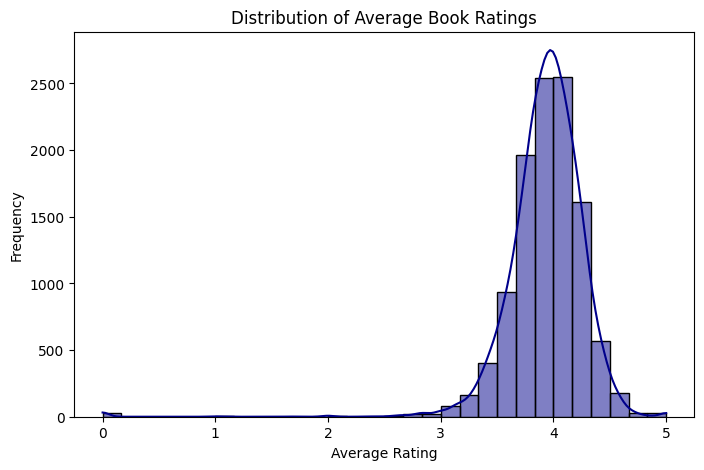

count    11127.000000
mean         3.933631
std          0.352445
min          0.000000
25%          3.770000
50%          3.960000
75%          4.135000
max          5.000000
Name: average_rating, dtype: float64


In [17]:
plt.figure(figsize=(8, 5))
sns.histplot(df['average_rating'], kde=True, bins=30, color='darkblue')
plt.title('Distribution of Average Book Ratings')
plt.xlabel('Average Rating')
plt.ylabel('Frequency')
plt.show()

print(df['average_rating'].describe())

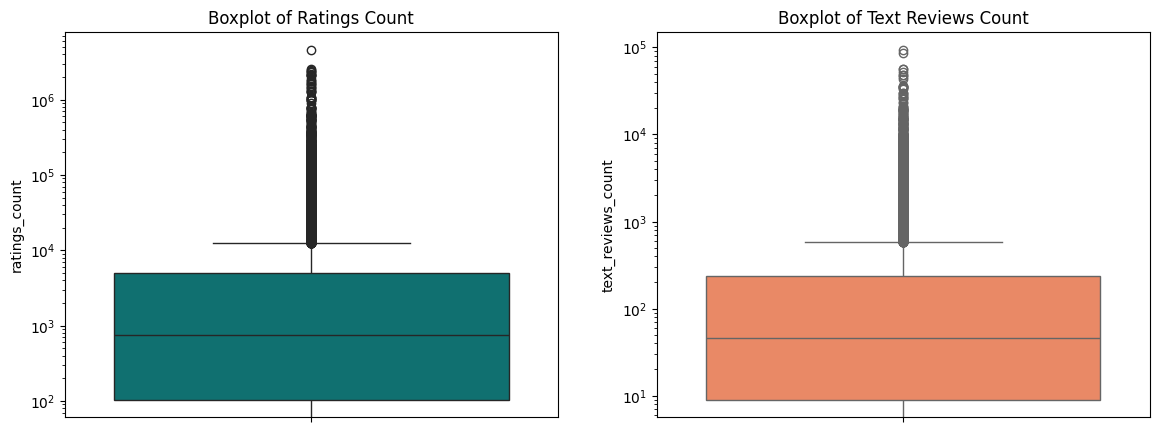

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(y=df['ratings_count'], ax=ax[0], color='teal')
ax[0].set_title('Boxplot of Ratings Count')
ax[0].set_yscale('log') # Using log scale because outliers are massive

sns.boxplot(y=df['text_reviews_count'], ax=ax[1], color='coral')
ax[1].set_title('Boxplot of Text Reviews Count')
ax[1].set_yscale('log')

plt.show()

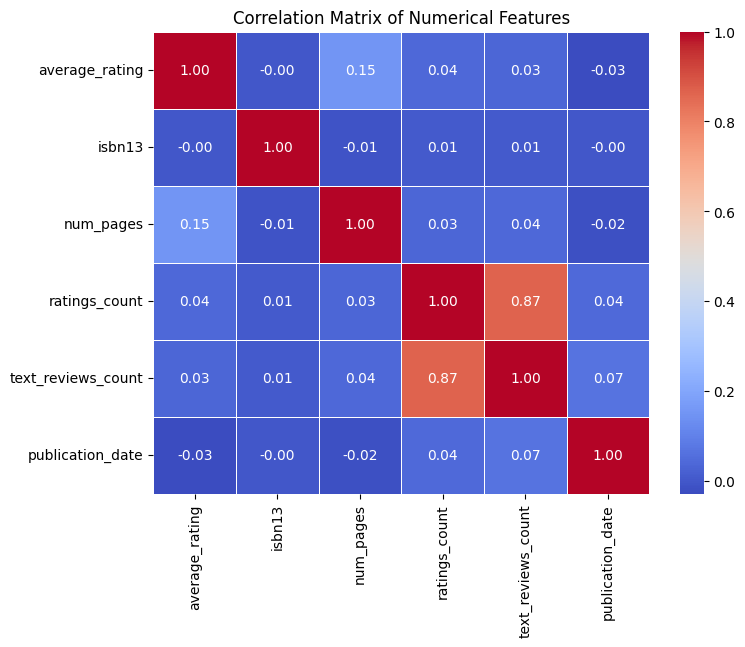

In [17]:
plt.figure(figsize=(8, 6))
numerical_cols = ['average_rating', 'isbn13', 'num_pages', 'ratings_count', 'text_reviews_count', 'publication_date']
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()